#### 1. 프로젝트 개요
- 목적: 시험 성적 예측을 위한 데이터 구조 파악 및 효율적인 전처리 공정 수립
- 데이터 출처: Kaggle - Student Performance Factors
- 데이터 출처 링크 : https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/data
- 데이터 구성: 총 20개 컬럼, 6607개 행

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_colwidth', None)

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=True)

In [101]:
data = pd.read_csv('StudentPerformanceFactors.csv')
display(data.shape)
display(data.head(3))

(6607, 20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74


#### 2. 데이터 기본 정보
- 총 데이터 수: 6607개
- 컬럼 수: 20개
- 주요 컬럼: `Hours_Studied`, `Attendance`, `Previous_Scores` 등



#### 3. **기술 통계 및 데이터 요약**

* 수치형 변수: 평균, 중앙값, 표준편차, 최소/최대
* 범주형 변수: 각 범주의 빈도수 및 비율

In [102]:
def line(s):
    l = "=" * (35-len(s)//2)
    print(l, s, l)

line("전체 칼럼")
display(data.columns)
line("수치형 데이터")
numeric_data = data.select_dtypes(include=np.number)
display(numeric_data.head(3))
line("범례형 데이터")
categoric_data = data.select_dtypes(exclude=np.number)
display(categoric_data.head(3))
line("수치형 데이터 통계")
display(numeric_data.agg(['mean','median','std','min','max']).T)
line("범례형 데이터 통계")
dist = pd.Series()
for col in categoric_data.columns:
    s= categoric_data[col].value_counts()/categoric_data[col].count() * 100

    result = ', '.join(f"{idx}({val:.3f})" for idx, val in s.items())
    dist[col] = result

cate_describe = categoric_data.describe().T
cate_describe['distribution'] = dist
display(cate_describe)


================================= 전체 칼럼 =================================


Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

================================ 수치형 데이터 ================================


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,23,84,7,73,0,3,67
1,19,64,8,59,2,4,61
2,24,98,7,91,2,4,74


================================ 범례형 데이터 ================================


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,Low,High,No,Low,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
1,Low,Medium,No,Low,Yes,Medium,Medium,Public,Negative,No,College,Moderate,Female
2,Medium,Medium,Yes,Medium,Yes,Medium,Medium,Public,Neutral,No,Postgraduate,Near,Male


============================== 수치형 데이터 통계 ==============================


,mean,median,std,min,max
Hours_Studied,19.975329,20.0,5.990594,1.0,44.0
Attendance,79.977448,80.0,11.547475,60.0,100.0
Sleep_Hours,7.029060,7.0,1.468120,4.0,10.0
Previous_Scores,75.070531,75.0,14.399784,50.0,100.0
Tutoring_Sessions,1.493719,1.0,1.230570,0.0,8.0
Physical_Activity,2.967610,3.0,1.031231,0.0,6.0
Exam_Score,67.235659,67.0,3.890456,55.0,101.0


============================== 범례형 데이터 통계 ==============================


,count,unique,top,freq,distribution
Parental_Involvement,6607,3,Medium,3362,"Medium(50.885), High(28.878), Low(20.236)"
Access_to_Resources,6607,3,Medium,3319,"Medium(50.235), High(29.893), Low(19.873)"
Extracurricular_Activities,6607,2,Yes,3938,"Yes(59.603), No(40.397)"
Motivation_Level,6607,3,Medium,3351,"Medium(50.719), Low(29.317), High(19.964)"
Internet_Access,6607,2,Yes,6108,"Yes(92.447), No(7.553)"
Family_Income,6607,3,Low,2672,"Low(40.442), Medium(40.351), High(19.207)"
Teacher_Quality,6529,3,Medium,3925,"Medium(60.116), High(29.821), Low(10.063)"
School_Type,6607,2,Public,4598,"Public(69.593), Private(30.407)"
Peer_Influence,6607,3,Positive,2638,"Positive(39.927), Neutral(39.231), Negative(20.842)"
Learning_Disabilities,6607,2,No,5912,"No(89.481), Yes(10.519)"


#### 4. **결측치 및 이상치 탐색**

* 각 컬럼의 결측치 수
* 이상치 탐색 방법: boxplot, IQR, 도수분포 등

In [103]:
# 결측치가 얼마나 있는지 확인
print("처리 전 결측치:\n", data.isnull().sum()[data.isnull().sum() > 0])

# 빈칸 처리하기 (방법 1: 빈칸이 있는 행을 아예 삭제해버리기)
# df_clean = df.dropna()

# 방법 2: 최빈값으로 채우기
categoric_data = categoric_data.fillna(categoric_data.mode().iloc[0])

print("\n처리 후 결측치:\n", categoric_data.isnull().sum().sum(), "개")

처리 전 결측치:
 Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

처리 후 결측치:
 0 개


1.0


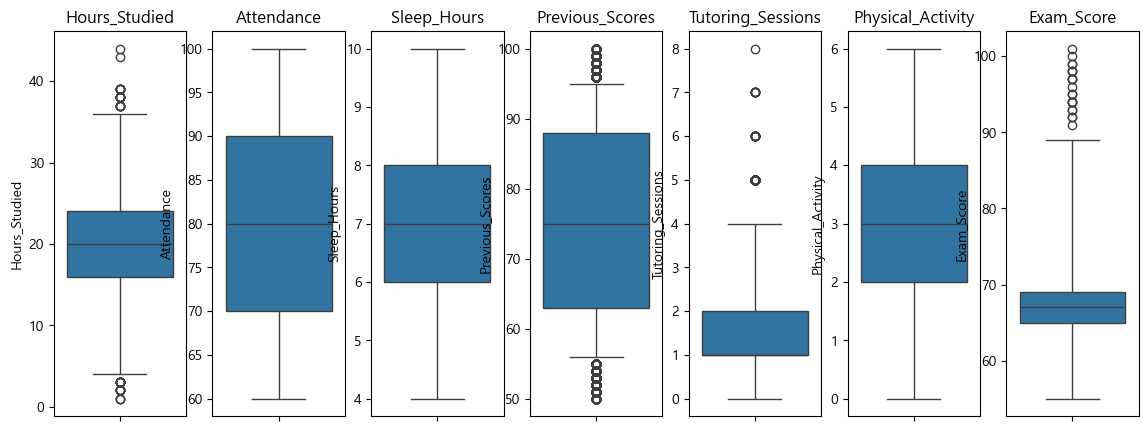

In [104]:
# 이상치 확인
size = numeric_data.columns.size
fig, ax = plt.subplots(1, size, figsize=(14,5))
whis_list = [1.5, 1, 1.5, 0.3, 2, 1.5, 5]

# Tutoring_Sessions 의 중앙값 확인 (박스플롯에서 보이지 않기 때문에)
print(numeric_data['Tutoring_Sessions'].median())
for i, col in enumerate(numeric_data.columns):
    sns.boxplot(numeric_data[col], ax= ax[i], whis=whis_list[i])
    ax[i].set_title(col)

# 100점이 넘는 이상치 제거
data.loc[data['Exam_Score'] > 100,'Exam_Score'] = 100

plt.show()

#### 5. **변수 간 관계 분석**

* 시각화: 히스토그램, 상자 그림, 산점도, heatmap
* 상관분석: 수치형 변수 간 상관계수
* 그룹 비교: 

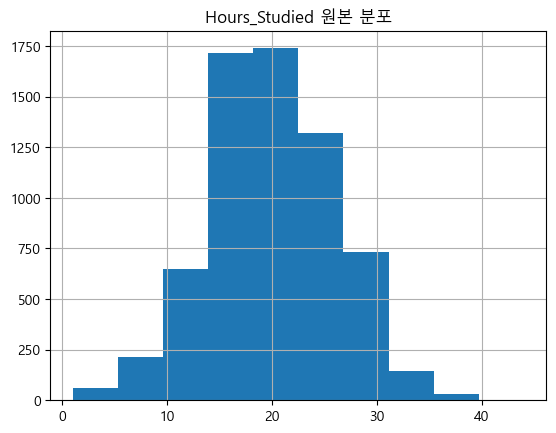

In [105]:
# 출석률 로그 변환 확인
data['Hours_Studied'].hist()
plt.title('Hours_Studied 원본 분포')
plt.show()

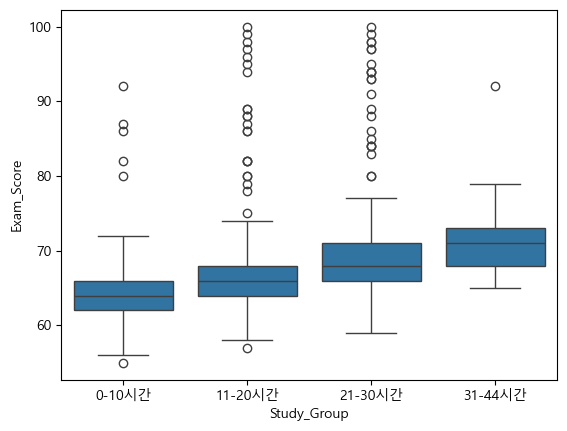

In [106]:
# 공부시간 구간화
data['Study_Group'] = pd.cut(
    data['Hours_Studied'],
    bins=[0, 10, 20, 30, 44],
    labels=['0-10시간', '11-20시간', '21-30시간', '31-44시간']
)

# 공부시간 구간과 시험 점수의 관계
sns.boxplot(data=data, x='Study_Group', y='Exam_Score',
            order=['0-10시간', '11-20시간', '21-30시간', '31-44시간'])
plt.show()

# 공부시간이 많을수록 시험 점수가 높아지는 경향이 나타난다. (유의미 해보임)

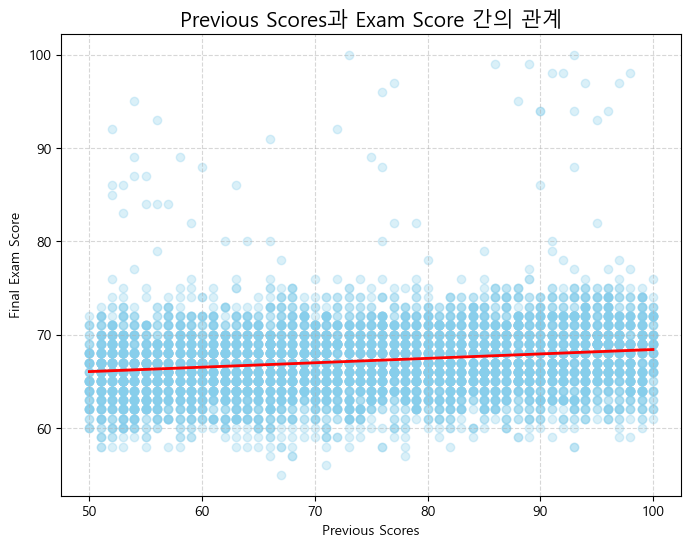

In [107]:
plt.figure(figsize=(8, 6))

sns.regplot(data=data, x='Previous_Scores', y='Exam_Score', 
            scatter_kws={'alpha':0.3, 'color':'skyblue'}, 
            line_kws={'color':'red', 'lw':2})

plt.title('Previous Scores과 Exam Score 간의 관계', fontsize=15)
plt.xlabel('Previous Scores')
plt.ylabel('Final Exam Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

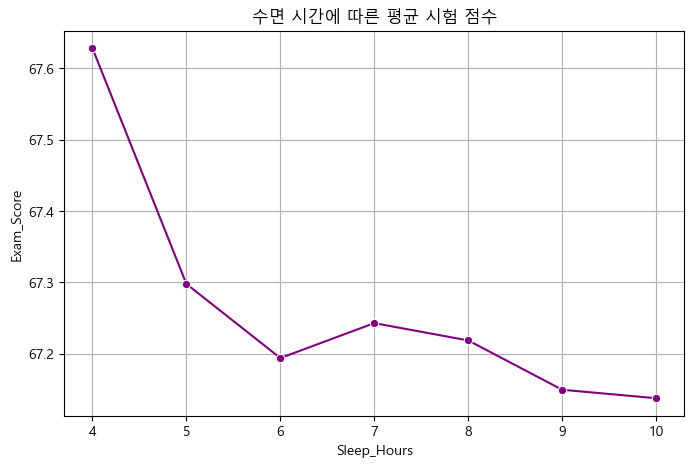

In [108]:
plt.figure(figsize=(8, 5))

# 수면 시간별 평균 점수를 계산하여 그래프 그리기
sleep_score = data.groupby('Sleep_Hours')['Exam_Score'].mean().reset_index()
sns.lineplot(data=sleep_score, x='Sleep_Hours', y='Exam_Score', marker='o', color='purple')
plt.title('수면 시간에 따른 평균 시험 점수')
plt.grid(True)
plt.show()

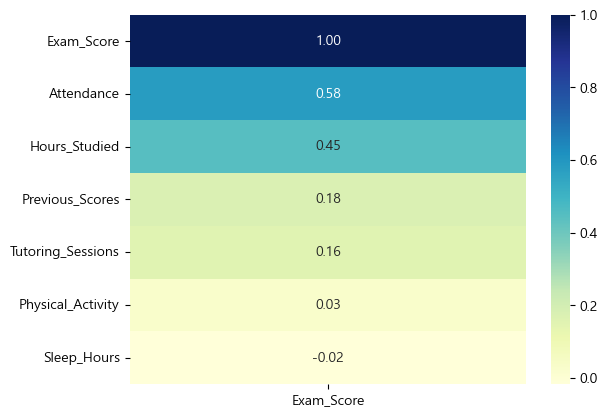

In [109]:
# heatmap

corr_mat = numeric_data.corr()[['Exam_Score']]
corr_mat = corr_mat.sort_values(by='Exam_Score', ascending=False)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='YlGnBu')
plt.show()

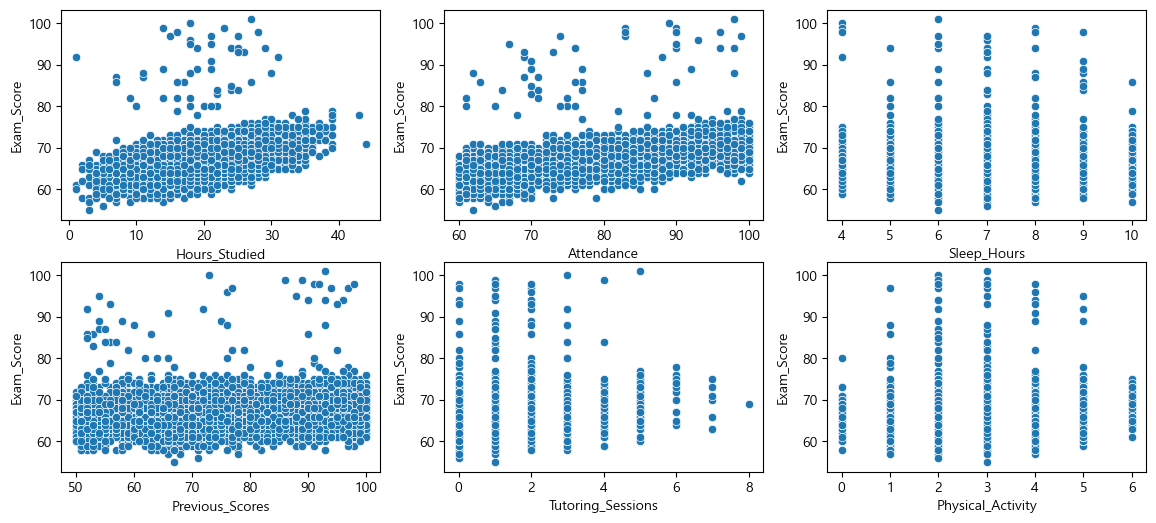

In [110]:
# 산점도
target_col = 'Exam_Score'
fig, ax = plt.subplots(2,3, figsize=(14,6))
ax = ax.flatten()
for i, col in enumerate(numeric_data.columns):
    if col == target_col:
        continue
    
    sns.scatterplot(x = numeric_data[col], y = numeric_data[target_col], ax=ax[i])

plt.show()

#### 6. **파생 변수 생성 및 전처리 제안**

* 범주형 그룹핑, 나이 구간화 등
* 로그변환, 정규화 여부

In [111]:
# 라벨 인코딩 - 범례형 데이터
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
encoded_data = pd.DataFrame()

for col in categoric_data:
    label_encoders[col] = LabelEncoder()
    encoded_data[col] = label_encoders[col].fit_transform(categoric_data[col])

# 부모영향력 종합 지표 생성
involvement_map = {'Low': 1, 'Medium': 2, 'High': 3}
education_map = {'High School': 1, 'College': 2, 'Postgraduate': 3} # 실제 데이터 값에 맞춰 수정 필요
income_map = {'Low': 1, 'Medium': 2, 'High': 3}

encoded_data['Parental_Impact_Score'] = (
    categoric_data['Parental_Involvement'].map(involvement_map) +
    categoric_data['Parental_Education_Level'].map(education_map) +
    categoric_data['Family_Income'].map(income_map)
)

encoded_data['Exam_Score'] = data['Exam_Score']
    
display(encoded_data.head(7))
display(encoded_data.corr()[['Exam_Score']])


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Parental_Impact_Score,Exam_Score
0,1,0,0,1,1,1,2,1,2,0,1,2,1,3,67
1,1,2,0,1,1,2,2,1,0,0,0,1,0,5,61
2,2,2,1,2,1,2,2,1,1,0,2,2,1,7,74
3,1,2,1,2,1,2,2,1,0,0,1,1,1,4,71
4,2,2,1,2,1,2,0,1,1,0,0,2,0,6,70
5,2,2,1,2,1,2,2,1,2,0,2,2,1,7,71
6,2,1,1,1,1,1,2,0,1,0,1,1,1,4,67


,Exam_Score
Parental_Involvement,-0.094310
Access_to_Resources,-0.090568
Extracurricular_Activities,0.064371
Motivation_Level,-0.014900
Internet_Access,0.051628
Family_Income,-0.026429
Teacher_Quality,-0.060787
School_Type,-0.008872
Peer_Influence,0.100208
Learning_Disabilities,-0.085081


In [112]:
def korean_grade(score, scores_series):
    # 상위 누적비율 기준 9등급 반환
    rank_pct = (scores_series >= score).mean() * 100  # 상위 몇 %인지

    if rank_pct <= 4:   return 1
    if rank_pct <= 11:  return 2
    if rank_pct <= 23:  return 3
    if rank_pct <= 40:  return 4
    if rank_pct <= 60:  return 5
    if rank_pct <= 77:  return 6
    if rank_pct <= 89:  return 7
    if rank_pct <= 96:  return 8
    return 9


In [113]:
# 구간화
binned_data = pd.DataFrame({
    'Previous_Scores': data['Previous_Scores'].apply(lambda x: korean_grade(x, data['Previous_Scores'])),
    'Hours_Studied': pd.cut(data['Hours_Studied'], bins=6),
    'Attendance': pd.qcut(data['Attendance'], q=6),
    'Exam_Score': data['Exam_Score'].apply(lambda x: korean_grade(x, data['Exam_Score']))
})

display(binned_data)


,Previous_Scores,Hours_Studied,Attendance,Exam_Score
0,5,"(22.5, 29.667]","(80.0, 87.0]",5
1,7,"(15.333, 22.5]","(59.999, 67.0]",9
2,3,"(22.5, 29.667]","(93.0, 100.0]",1
3,2,"(22.5, 29.667]","(87.0, 93.0]",3
4,6,"(15.333, 22.5]","(87.0, 93.0]",4
...,...,...,...,...
6602,5,"(22.5, 29.667]","(67.0, 73.0]",5
6603,4,"(22.5, 29.667]","(73.0, 80.0]",4
6604,6,"(15.333, 22.5]","(87.0, 93.0]",5
6605,3,"(8.167, 15.333]","(80.0, 87.0]",5


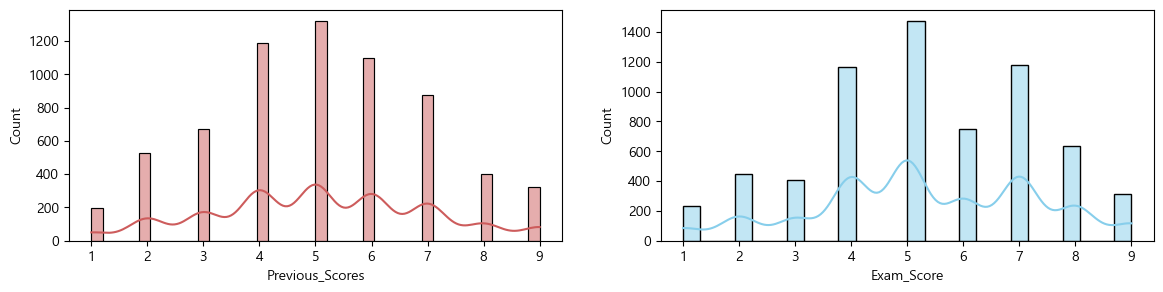

In [114]:
_, ax = plt.subplots(1,2, figsize=(14,3))
sns.histplot(binned_data['Previous_Scores'], kde=True, color='indianred', ax=ax[0])
sns.histplot(binned_data['Exam_Score'], kde=True, color='skyblue', ax=ax[1])

plt.show()

In [115]:
display(np.percentile(data['Previous_Scores'], [0, 4, 11, 23, 40, 60, 77, 89, 96, 100]))
display(np.percentile(data['Exam_Score'], [0, 4, 11, 23, 40, 60, 77, 89, 96, 100]))

array([ 50.,  52.,  55.,  62.,  70.,  80.,  89.,  94.,  98., 100.])

array([ 55.,  61.,  63.,  65.,  66.,  68.,  70.,  71.,  73., 100.])

c:\Users\Playdata\AppData\Local\miniforge3\envs\ai_basic\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\Playdata\AppData\Local\miniforge3\envs\ai_basic\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


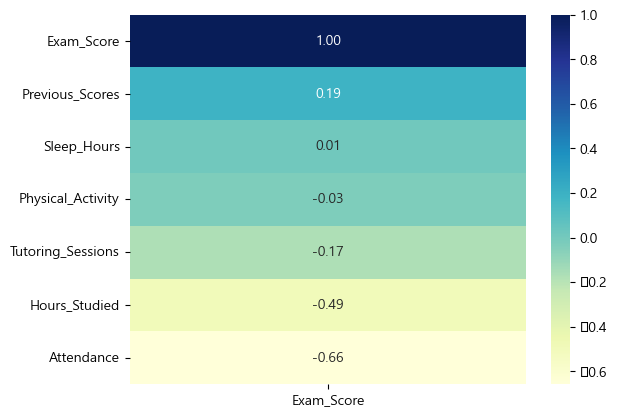

In [116]:
merged_binned = numeric_data.drop('Exam_Score', axis=1)
merged_binned['Exam_Score'] = binned_data['Exam_Score']
merged_binned['Previous_Scores'] = binned_data['Previous_Scores']
corr_mat = merged_binned.corr()[['Exam_Score']]
corr_mat = corr_mat.sort_values(by='Exam_Score', ascending=False)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='YlGnBu')
plt.show()

c:\Users\Playdata\AppData\Local\miniforge3\envs\ai_basic\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\Playdata\AppData\Local\miniforge3\envs\ai_basic\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


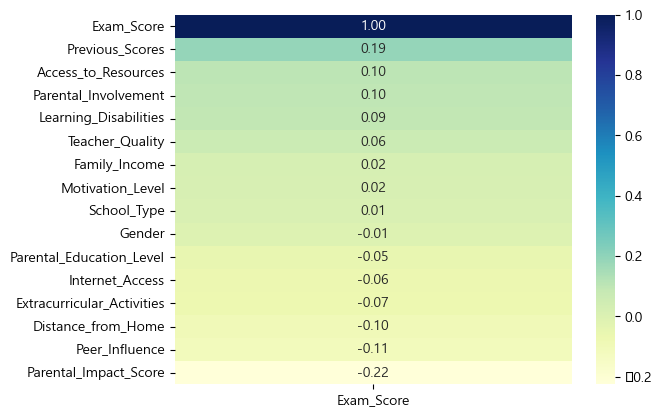

In [117]:
# heatmap2 (라벨인코드 범례형 데이터 + 구간화된 결과 데이터)
merged_numeric = encoded_data.drop(['Exam_Score'], axis=1)
merged_numeric['Previous_Scores'] = binned_data['Previous_Scores']
merged_numeric['Exam_Score'] = binned_data['Exam_Score']
corr_mat = merged_numeric.corr()[['Exam_Score']]
corr_mat = corr_mat.sort_values(by='Exam_Score', ascending=False)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='YlGnBu')
plt.show()

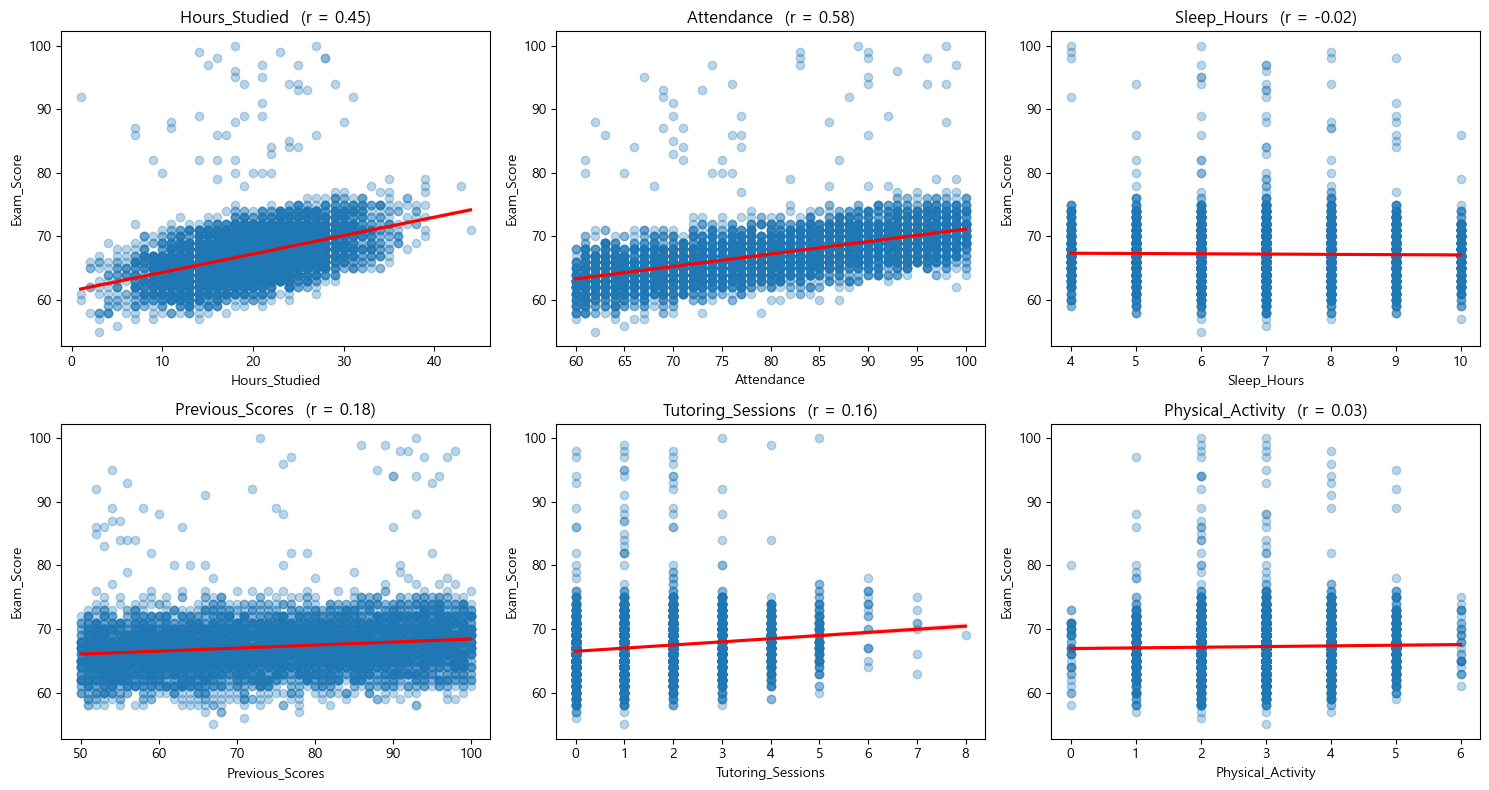

In [118]:
import math

target = 'Exam_Score'
features = [c for c in data.select_dtypes('number').columns if c != target]

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    r = data[[col, target]].corr().iloc[0, 1]
    sns.regplot(x=col, y=target, data=data, ax=axes[i],
                scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
    axes[i].set_title(f'{col}  (r = {r:.2f})')

# 남는 axes 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

In [119]:
# Hours_Studied, Attendance 표준편차 비교
print('std of Hours_Studied : ', data['Hours_Studied'].std())
print('std of Attendans : ', data['Attendance'].std())

std of Hours_Studied :  5.9905943365787415
std of Attendans :  11.547474961482814


### 상관관계 수치에 대한 해석
* | 0.00 ~ 0.09 | 무시할 수준 (Negligible) | 사실상 선형 관계 없음 |
* | 0.10 ~ 0.29 | 약한 상관 (Weak) | 관계가 존재하나 예측력 낮음 |
* | 0.30 ~ 0.49 | 보통 상관 (Moderate) | 실질적 관련성이 있음 |
* | 0.50 ~ 0.69 | 강한 상관 (Strong) | 뚜렷한 선형 경향 |
* | 0.70 ~ 0.89 | 매우 강한 상관 (Very Strong) | 높은 예측력 |
* | 0.90 ~ 1.00 | 거의 완벽한 상관 (Near Perfect) | 거의 직선 관계 |


### 지표 분류
* 강한 상관 관계 지표 : Attendance
* 보통 상관 관계 지표 : Hours_Studied
* 약한 상관 관계 지표 : Previous_Scores, Tutoring_Sessions

#### 7. 요약 및 인사이트
1) 주요 분석 결과
- **성실함이 만드는 성적의 차이** : 
출석률`Attendance`과 공부 시간`Hours_Studied`이 성적`Exam_Score`을 가장 잘 설명하는 핵심 변수임이 확인됨. 이는 해당 시험이 고도의 사고력보다는 많은 문항 수와 긴 시간을 견뎌내는 인내심과 성실함을 요구하는 구조임을 시사함.

- **외부적 요인의 미미한 영향력**: 
교육 자원이나 가정 환경`Educational Resources & Environment`(`Access to Resources`, `Extracurricular Activities`, `Internet Access`, `Teacher Quality`, `School Type` ,`Tutoring Sessions`)을 통합 지표로 분석하면 `Exam_Score`과의 상관관계가 0.2로 약한 상관관계가 형성된다.

- **내적 동기의 제한적 영향** : 
내적동기`Motivation_Level`와 최종 성적`Exam_Score` 간의 상관관계는 0.08로 영향력이 미미하며, 동기 수준이 낮든 높든 성적에 큰 차이가 없음을 의미함.

- **데이터 무결성 검토 필요** : 
`Exam_Score`의 최댓값이 101점으로 집계된 것은 일반적인 만점 체계를 벗어난 수치이므로, 단순 기입 오류(Typo)일 가능성에 대한 검토가 필요함.

1) 최종 결론 및 제안
- 전반적으로 시험성적을 볼 때, 특정 외부 요인이 성적에 크게 영향을 미칠만한 요소는 보이지 않았음. 
- 이전 성적과 최종 성적의 상관관계는 높지 않았고, 출석 및 학습시간에 대한 상관관계가 높게 형석되어 있음을 확인함.
- 시험의 성격 면에서도 고난도 문제를 변별력으로 주기보다는, 문항 수가 많고 시험 시간이 길어 높은 집중력과 체력을 요구했을 것으로 판단됨
- 따라서 이 데이터 상에서 향후 성적 향상을 위해서는 환경 개선이나 동기 부여 같은 추상적인 접근 보다는 가장 확실한 상관 관계를 보인 학습 시간 확보와 출석 관리라는 실질적인 노력에 집중할 것을 제안함.

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np


# x와 y분리
X = numeric_data.drop('Exam_Score', axis=1)
y = numeric_data['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 피처 스케일링 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

# 학습
model = LinearRegression() # 선형 회귀 모델 
model.fit(X_train_scaled, y_train) 

# 테스트
y_pred = model.predict(X_test_scaled) 

# 평가지표
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, y_pred)

print("RMSE 회귀 모델 평가 결과 ")
print(f"1. RMSE (평균 오차) : 약 {rmse:.2f}점")
print(f"2. 결정계수 (R-squared) : {r2:.4f}")


# 실제 점수와 모델이 예측한 점수 
comparison_df = pd.DataFrame({
    '실제 점수': y_test, 
    '모델 예측 점수': np.round(y_pred, 1)
})
comparison_df['오차'] = comparison_df['실제 점수'] - comparison_df['모델 예측 점수']
display(comparison_df.head(10))

RMSE 회귀 모델 평가 결과 
1. RMSE (평균 오차) : 약 2.25점
2. 결정계수 (R-squared) : 0.6416


,실제 점수,모델 예측 점수,오차
743,65,66.1,-1.1
5551,65,67.3,-2.3
3442,71,68.4,2.6
6571,64,66.8,-2.8
4204,66,65.7,0.3
2516,66,68.0,-2.0
4047,72,70.2,1.8
1706,66,67.3,-1.3
1075,70,68.9,1.1
233,70,67.9,2.1
